In [ ]:
# Install needed libraries

!pip install langchain -q
!pip install langgraph -q
!pip install langchain-openai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 30.0 MB/s eta 0:00:00


In [ ]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage

In [ ]:
class AgentState(TypedDict):
  messages : List[HumanMessage]

In [ ]:
# Get LLM API Key from ENV

import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")

In [ ]:
# Initialize the LLM

import os
from langchain_openai.chat_models import ChatOpenAI

llm = ChatOpenAI(
    model_name="gpt-4o",
    temperature=0.1,
)

In [ ]:
def chatbot(state : AgentState) -> AgentState:
  response = llm.invoke(state["messages"])
  print(f"\nAI : {response.content}")
  return state

In [ ]:
from langgraph.graph import StateGraph, START, END

In [ ]:
# Define Sequential Workflow

workflow= StateGraph(AgentState)

workflow.add_node("chatbot",chatbot)

workflow.add_edge(START,"chatbot")
workflow.add_edge("chatbot",END)

app= workflow.compile()

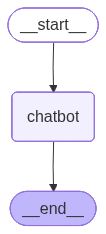

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
prompt = input("Enter your prompt here: ")
result= app.invoke({"messages": [HumanMessage(content=prompt)]})
print(result)

Enter your prompt here: How abot Widya Ruhuna Givinena mobile appliocation

AI : It seems like you might be referring to a specific mobile application, but there might be a typo or some confusion in the name. As of my last update in October 2023, I don't have any information on an application called "Widya Ruhuna Givinena." It's possible that it could be a regional or niche application, or it might have been released after my last update.

If you can provide more context or correct the name, I might be able to help you better. Alternatively, you might want to check the official app stores or the developer's website for more information about the application.
{'messages': [HumanMessage(content='How abot Widya Ruhuna Givinena mobile appliocation', additional_kwargs={}, response_metadata={})]}


In [ ]:
# For conversational looping chat

prompt = input("Enter your prompt here: ")
while prompt != "Exist":
  result= app.invoke({"messages": [HumanMessage(content=prompt)]})
  print(result)
  prompt = input("Enter your prompt here: ")

Enter your prompt here: hello

AI : Hello! How can I assist you today?
{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={})]}
Enter your prompt here: What is the highest commercial crop in Sri Lankan growing

AI : Tea is the highest commercial crop in Sri Lanka. The country is renowned for its Ceylon tea, which is a significant contributor to its economy. Sri Lanka is one of the world's largest exporters of tea, and the industry plays a crucial role in employment and foreign exchange earnings for the country.
{'messages': [HumanMessage(content='What is the highest commercial crop in Sri Lankan growing', additional_kwargs={}, response_metadata={})]}
Enter your prompt here: Exit

AI : It seems like you might be looking to end our conversation. If you have any other questions or need further assistance, feel free to ask. Otherwise, have a great day!
{'messages': [HumanMessage(content='Exit', additional_kwargs={}, response_metadata={})]}
Enter your prompt

#For Considering Chat History

In [ ]:
from typing import Union
from langchain_core.messages import AIMessage

In [ ]:
class AgentState(TypedDict):
  messages : List[Union[HumanMessage,AIMessage]]  # Union demmama Ai msg or human msg oni ekak store krgnn puluvn

In [ ]:
def chatbot(state : AgentState) -> AgentState:
  response = llm.invoke(state["messages"])
  state["messages"].append(AIMessage(response.content))  # Dena response ekath list ekatama append krnva
  print(f"\nAI : {response.content}")
  return state

In [ ]:
# For keeping chat history

history=[]

prompt = input("Enter your prompt here: ")
while prompt != "Exist":
  history.append(HumanMessage(content=prompt))   # human prompt eka add wenava
  result= app.invoke({"messages": history})  # full conersational history ekma denava eyata
  history = result["messages"]  # AI response ekea add wenva
  print(result)
  prompt = input("Enter your prompt here: ")

Enter your prompt here: hello

AI : Hello! How can I assist you today?
{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={})]}
Enter your prompt here: I'm Neno

AI : Hello, Neno! How can I assist you today?
{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}), HumanMessage(content="I'm Neno", additional_kwargs={}, response_metadata={})]}
Enter your prompt here: Who am I

AI : Hello, Neno! You just introduced yourself, so I know your name. Beyond that, I don't have any personal information about you. If you'd like to share more about yourself or if you have any questions, feel free to let me know!
{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}), HumanMessage(content="I'm Neno", additional_kwargs={}, response_metadata={}), HumanMessage(content='Who am I', additional_kwargs={}, response_metadata={})]}
Enter your prompt here: Thank youi

AI : Hello Neno! It seems like you're introdu

In [ ]:
history

[HumanMessage(content='hello', additional_kwargs={}, response_metadata={}),
 HumanMessage(content="I'm Neno", additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Who am I', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Thank youi', additional_kwargs={}, response_metadata={})]